# Nepal Rainfall Exploration


## Table of Contents

- **[Project Overview](#Project-Overview)** — motivation, research question, data source summary
- **[Data Collection](#Data-Collection)** — how the NASA POWER rainfall dataset was gathered via API
- **[Stage 1: Understand the Data](#Stage-1:-Understand-the-Data)** — structure, data types, missing values, date range, duplicates, value ranges
- **[Stage 2: Data Cleaning](#Stage-2:-Data-Cleaning)** — date features, monsoon season definition, grid coverage notes
- **[Stage 3: Exploratory Data Analysis](#Stage-3:-Exploratory-Data-Analysis)** — monthly rainfall patterns, annual trends, literature comparison
- **[Stage 4: Extreme Rainfall Events](#Stage-4:-Extreme-Rainfall-Events)** — percentile thresholds, frequency/intensity trends, geographic hotspots, map
- **[Stage 5: Flood-Risk Connection](#Stage-5:-Flood-Risk-Connection)** — EM-DAT flood data, matching flood events to rainfall, outlier investigation
- **[Stage 6: Visualization](#Stage-6:-Visualization-(integrated-throughout))** — note on visualizations integrated throughout
- **[Stage 7: Conclusions](#Stage-7:-Conclusions)** — key findings, limitations, future improvements

## Project Overview

**Motivation:** This project was motivated by the devastating flash floods that struck Nepal on August 26, 2026 (a glacier collapse and landslide near Langtang, resulting in over 1,000 deaths). While that specific disaster was driven by a glacial lake outburst rather than rainfall, it raised a broader question worth investigating with data: what do historical rainfall patterns tell us about Nepal's climate and flood risk more generally?

**Research Question:** What can historical rainfall data tell us about rainfall patterns and potential flood risk in Nepal?

**Data Source:** [NASA POWER](https://power.larc.nasa.gov/) (Prediction of Worldwide Energy Resources) a free public API providing satellite-based daily precipitation estimates. Chosen because Nepal's ground weather stations are sparse (especially in mountainous areas) and Nepal's own DHM doesn't offer easy bulk historical downloads. NASA POWER provides consistent, whole-country satellite coverage and is a credible, citable source.

- **Variable used:** `PRECTOTCORR` (Precipitation Corrected) bias-corrected daily rainfall in mm
- **Coverage:** Regional bounding box covering all of Nepal (Latitude 26.3–30.5, Longitude 80.0–88.3) → 126 grid points across the country
- **Time period:** January 1, 2001 – December 31, 2023 (23 years of daily data)
- **Collection method:** NASA POWER's website only allows 1-year regional downloads, so data was collected via NASA's public API directly in Python, looping through each year and combining results into a single dataset:  1,058,400 rows total (126 points × ~365 days × 23 years)

### Import Libraries

In [28]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from scipy import stats
import folium
import geopandas as gpd
from shapely.geometry import Point

## Data Collection

Rather than manually downloading data through the NASA POWER website, which only allows a 1-year date range per regional request. We collected the data programmatically using NASA POWER's public API in Python. This let us pull the full 23-year period we needed and automate the process end-to-end.

**Our approach:**

1. **Test the connection** — First, we sent a single request for one grid point and one year (2023) to confirm the API worked and to understand the structure of the response before scaling up.

2. **Understand the response structure** — NASA POWER returns data in a nested JSON format: a list of grid point "features," each containing its coordinates and a dictionary of daily rainfall values. We explored this structure step by step to figure out exactly where the dates and rainfall values were stored.

3. **Build a single-point-in-time DataFrame** — Once we understood the structure, we converted just one grid point's data into a simple pandas table (date + rainfall) to confirm our extraction logic worked correctly.

4. **Scale up to all grid points** — We then looped through all 126 grid points returned for Nepal's bounding box (Latitude 26.3–30.5, Longitude 80.0–88.3), combining each point's location and daily rainfall into one long table.

5. **Automate across all 23 years** — Since the API also limits each regional request to about 1 year, we wrote a loop that repeated the process for every year from 2001 to 2023, pausing 1 second between requests to avoid overloading NASA's server. This produced a combined dataset of 1,058,400 rows (126 grid points × ~365 days × 23 years).

6. **Save the dataset locally** — The combined dataset was saved as `nepal_rainfall_2001_2023.csv`, so the full download process (which takes a few minutes) never needs to be repeated from this point on, we simply reload the saved CSV.

**Note:** This dataset is too large to open directly in Excel (which has a ~1,048,576 row limit), but pandas handles it without any issue. We verified the saved file by reloading it and confirming the row count matched.

In [1]:
import requests

url = "https://power.larc.nasa.gov/api/temporal/daily/regional"
params = {
    "start": "20230101",
    "end": "20231231",
    "latitude-min": 26.3,
    "latitude-max": 30.5,
    "longitude-min": 80.0,
    "longitude-max": 88.3,
    "community": "AG",
    "parameters": "PRECTOTCORR",
    "format": "JSON"
}

response = requests.get(url, params=params)
print(response.status_code)

200


In [2]:
data = response.json()
print(type(data))
print(data.keys())


<class 'dict'>
dict_keys(['features', 'header', 'messages', 'parameters', 'times', 'type'])


In [3]:
print(len(data['features']))
print(data['features'][0].keys())

126
dict_keys(['type', 'geometry', 'properties'])


In [4]:
print(data['features'][0]['geometry'])
print(data['features'][0]['properties'].keys())

{'type': 'Point', 'coordinates': [80.0, 26.5, 130.11]}
dict_keys(['parameter'])


In [5]:
param_data = data['features'][0]['properties']['parameter']
print(param_data.keys())

dict_keys(['PRECTOTCORR'])


In [6]:
rainfall_series = param_data['PRECTOTCORR']
print(len(rainfall_series))

# print first 5 date-value pairs
list(rainfall_series.items())[:5]


365


[('20230101', 0.0),
 ('20230102', 0.0),
 ('20230103', 0.0),
 ('20230104', 0.0),
 ('20230105', 0.0)]

In [9]:
df_one_point = pd.DataFrame(list(rainfall_series.items()), columns=['date', 'rainfall_mm'])
df_one_point.head()

,date,rainfall_mm
0,20230101,0.0
1,20230102,0.0
2,20230103,0.0
3,20230104,0.0
4,20230105,0.0


In [10]:
all_rows = []

for feature in data['features']:
    lon, lat, elev = feature['geometry']['coordinates']
    rainfall = feature['properties']['parameter']['PRECTOTCORR']
    
    for date, value in rainfall.items():
        all_rows.append({
            'date': date,
            'latitude': lat,
            'longitude': lon,
            'rainfall_mm': value
        })

df = pd.DataFrame(all_rows)
print(df.shape)
df.head()

(45990, 4)


,date,latitude,longitude,rainfall_mm
0,20230101,26.5,80.0,0.0
1,20230102,26.5,80.0,0.0
2,20230103,26.5,80.0,0.0
3,20230104,26.5,80.0,0.0
4,20230105,26.5,80.0,0.0


In [11]:
df.to_csv('nepal_rainfall_2023_test.csv', index=False)
print("saved")

saved


In [13]:

all_years_rows = []

for year in range(2001, 2024):
    print(f"Downloading {year}...")
    
    params = {
        "start": f"{year}0101",
        "end": f"{year}1231",
        "latitude-min": 26.3,
        "latitude-max": 30.5,
        "longitude-min": 80.0,
        "longitude-max": 88.3,
        "community": "AG",
        "parameters": "PRECTOTCORR",
        "format": "JSON"
    }
    
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print(f"  FAILED for {year}, status code: {response.status_code}")
        continue
    
    year_data = response.json()
    
    for feature in year_data['features']:
        lon, lat, elev = feature['geometry']['coordinates']
        rainfall = feature['properties']['parameter']['PRECTOTCORR']
        for date, value in rainfall.items():
            all_years_rows.append({
                'date': date,
                'latitude': lat,
                'longitude': lon,
                'rainfall_mm': value
            })
    
    time.sleep(1)  # small pause to be polite to NASA's server

print("Done downloading all years!")

Done downloading all years!


In [14]:
df_all = pd.DataFrame(all_years_rows)
print(df_all.shape)
df_all.head()

(1058400, 4)


,date,latitude,longitude,rainfall_mm
0,20010101,26.5,80.0,2.03
1,20010102,26.5,80.0,0.00
2,20010103,26.5,80.0,0.00
3,20010104,26.5,80.0,0.00
4,20010105,26.5,80.0,0.00


In [15]:
df_all.to_csv('nepal_rainfall_2001_2023.csv', index=False)
print("saved full dataset")

saved full dataset


In [16]:
check = pd.read_csv('nepal_rainfall_2001_2023.csv')
print(check.shape)
check.head()

(1058400, 4)


,date,latitude,longitude,rainfall_mm
0,20010101,26.5,80.0,2.03
1,20010102,26.5,80.0,0.00
2,20010103,26.5,80.0,0.00
3,20010104,26.5,80.0,0.00
4,20010105,26.5,80.0,0.00


## Stage 1: Understand the Data


We begin by loading the rainfall dataset we collected and saved earlier (`nepal_rainfall_2001_2023.csv`), so we can pick up the analysis without repeating the NASA API download process.

Once loaded, we check the structure of the dataset, data types, missing values, and row counts before doing any analysis.

In [2]:
df = pd.read_csv('nepal_rainfall_2001_2023.csv')
print(df.shape)
df.head()

(1058400, 4)


,date,latitude,longitude,rainfall_mm
0,20010101,26.5,80.0,2.03
1,20010102,26.5,80.0,0.00
2,20010103,26.5,80.0,0.00
3,20010104,26.5,80.0,0.00
4,20010105,26.5,80.0,0.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058400 entries, 0 to 1058399
Data columns (total 4 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   date         1058400 non-null  int64  
 1   latitude     1058400 non-null  float64
 2   longitude    1058400 non-null  float64
 3   rainfall_mm  1058400 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 32.3 MB


### Converting the date column

The `date` column was loaded as a plain number (e.g. `20010101`) rather than an actual date, since that's how it came through from the JSON response. We convert it to pandas' datetime format so we can later extract the year, month, and season, and so pandas can properly sort and filter by date.

In [4]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058400 entries, 0 to 1058399
Data columns (total 4 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   date         1058400 non-null  datetime64[ns]
 1   latitude     1058400 non-null  float64       
 2   longitude    1058400 non-null  float64       
 3   rainfall_mm  1058400 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 32.3 MB


### Checking the date range

Before analyzing rainfall patterns, we confirm the dataset actually spans the full period we requested (2001–2023), with no unexpected gaps.

In [5]:
print(df['date'].min())
print(df['date'].max())

2001-01-01 00:00:00
2023-12-31 00:00:00


### Checking for duplicates

We check whether any rows are exact duplicates, which could happen due to overlapping grid points or an error in the download loop.

In [6]:
print(df.duplicated().sum())

0


### Checking value ranges

We check the rainfall values themselves for anything suspicious ( negative numbers, which are physically impossible for rainfall) or extreme outliers that might indicate bad data rather than real weather.

In [7]:
df['rainfall_mm'].describe()

count    1.058400e+06
mean     2.428394e+00
std      6.700644e+00
min      0.000000e+00
25%      0.000000e+00
50%      4.000000e-02
75%      1.750000e+00
max      4.649200e+02
Name: rainfall_mm, dtype: float64

### Summary: Stage 1 complete

- 1,058,400 rows covering 126 grid points across Nepal, daily rainfall from 2001–2023
- No missing values, no duplicate rows
- Date column converted to proper datetime format
- Rainfall values range from 0mm to 464.92mm/day. No negative values, and the maximum is plausible given Nepal's known monsoon extremes

The dataset appears clean and ready for exploratory analysis.

## Stage 2: Data Cleaning

Stage 1 showed the dataset has no missing values, no duplicates, and no invalid rainfall values, so minimal cleaning is required.

In this stage we:
- Create useful date-based columns (year, month, season) for analysis
- Note the handling of grid points near Nepal's borders

In [8]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df.head()

,date,latitude,longitude,rainfall_mm,year,month
0,2001-01-01,26.5,80.0,2.03,2001,1
1,2001-01-02,26.5,80.0,0.00,2001,1
2,2001-01-03,26.5,80.0,0.00,2001,1
3,2001-01-04,26.5,80.0,0.00,2001,1
4,2001-01-05,26.5,80.0,0.00,2001,1


### Defining monsoon season

According to Nepal's Department of Hydrology and Meteorology (DHM), the monsoon season runs from June 1 to September 30, contributing around 80% of Nepal's total annual rainfall (source: DHM, https://www.dhm.gov.np/).

Note: actual monsoon onset and withdrawal dates vary somewhat each year (typically by a few days to a couple of weeks). We use the fixed June–September window as a standard, consistent definition across all years, rather than adjusting it year by year.

We create a `season` column to label each row as "Monsoon" or "Non-Monsoon" based on this definition.

In [9]:
df['season'] = df['month'].apply(lambda m: 'Monsoon' if m in [6, 7, 8, 9] else 'Non-Monsoon')

df[['date', 'month', 'season']].head()

,date,month,season
0,2001-01-01,1,Non-Monsoon
1,2001-01-02,1,Non-Monsoon
2,2001-01-03,1,Non-Monsoon
3,2001-01-04,1,Non-Monsoon
4,2001-01-05,1,Non-Monsoon


### Note on grid coverage

Since we used a rectangular bounding box to request data, a small number of the 126 grid points may fall just outside Nepal's actual borders (in neighboring India or China). For country-wide averages and time-based patterns, this has negligible impact. If more precise geographic analysis is done later (e.g., district-level comparisons), we will filter points using Nepal's actual boundary shape at that time.

##### Stage 2 complete, moving to Exploratory Data Analysis

## Stage 3: Exploratory Data Analysis

### Monthly rainfall patterns

We look at how rainfall varies across the months of the year, averaged over all 23 years and all 126 locations. This helps confirm and visualize Nepal's monsoon season versus dry season.

In [10]:
monthly_avg = df.groupby('month')['rainfall_mm'].mean()
monthly_avg

month
1     0.407971
2     0.676524
3     0.598782
4     0.843992
5     1.995877
6     4.184166
7     7.986364
8     6.528470
9     4.181127
10    1.286014
11    0.091298
12    0.189574
Name: rainfall_mm, dtype: float64

We visualize the monthly averages as a bar chart to make the seasonal pattern immediately clear.

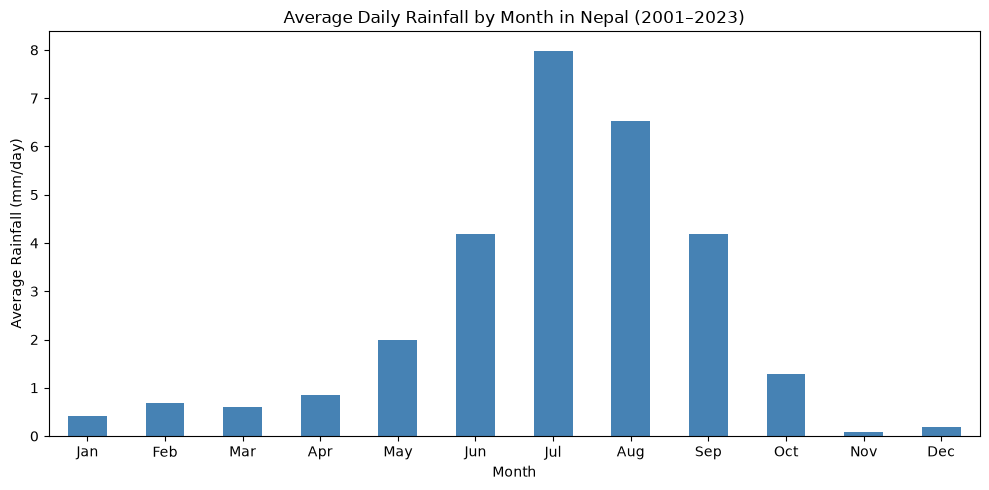

In [11]:


monthly_avg.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title('Average Daily Rainfall by Month in Nepal (2001–2023)')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm/day)')
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Rainfall is heavily concentrated in the monsoon months (June–September), with July as the peak (~8mm/day average). Nearly the entire dry season (November–February) sees rainfall below 1mm/day on average. This matches DHM's reported figure that monsoon season contributes around 80% of Nepal's annual rainfall.

### Verifying the 80% monsoon contribution claim

We check what percentage of total rainfall in our dataset actually falls during the monsoon season (June–September), to see if it matches DHM's reported ~80% figure.

In [12]:
season_totals = df.groupby('season')['rainfall_mm'].sum()
season_pct = season_totals / season_totals.sum() * 100
season_pct

season
Monsoon        79.030902
Non-Monsoon    20.969098
Name: rainfall_mm, dtype: float64

**Result:** Our dataset shows monsoon season (June–September) accounts for 79.03% of total rainfall, closely matching DHM's reported ~80% figure. This gives us confidence that our NASA POWER dataset accurately reflects Nepal's real-world rainfall patterns, and validates the dataset as a reliable basis for the rest of this analysis.

### Annual rainfall trends

We now look at how total rainfall across Nepal has changed year by year from 2001 to 2023. This is directly relevant to our climate-change question: Is there evidence of increasing, decreasing, or fluctuating rainfall over this period?

In [13]:
annual_total = df.groupby('year')['rainfall_mm'].sum()
annual_total

year
2001     71774.92
2002     58886.61
2003     70142.98
2004    100269.89
2005    102722.09
2006     97160.52
2007    121482.33
2008    134583.29
2009     91116.48
2010    107912.80
2011    119866.41
2012     99168.35
2013    138706.69
2014    112660.76
2015    109990.24
2016    116155.74
2017    116650.25
2018    119269.91
2019    127354.39
2020    145181.58
2021    162509.44
2022    128851.55
2023    117795.44
Name: rainfall_mm, dtype: float64

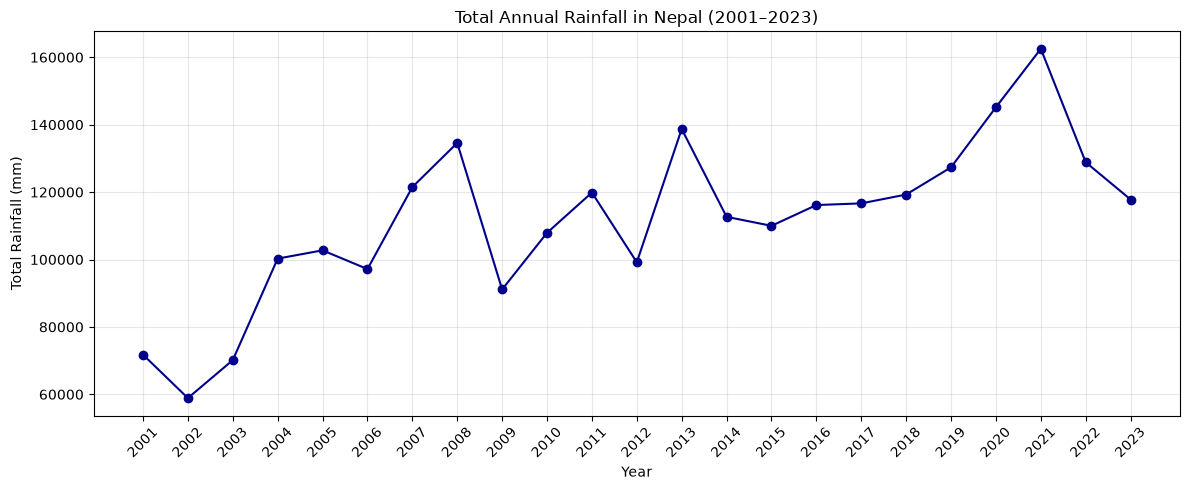

In [14]:
annual_total.plot(kind='line', figsize=(12,5), marker='o', color='darkblue')
plt.title('Total Annual Rainfall in Nepal (2001–2023)')
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.xticks(ticks=annual_total.index, labels=annual_total.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:


years = annual_total.index
values = annual_total.values

slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)

print(f"Slope: {slope:.2f} mm per year")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.4f}")

Slope: 2656.76 mm per year
R-squared: 0.553
P-value: 0.0000


**Result:** A linear trend test shows a statistically significant increase in total annual rainfall over 2001–2023 (p < 0.0001), with the trend explaining about 55% of year to year variation (R² = 0.553). This confirms the upward pattern seen in the chart is unlikely to be due to random chance alone but the moderate R² also shows substantial year to year variability remains, likely driven by natural climate cycles (e.g., monsoon strength, ENSO) rather than a smooth, steady increase.

**Important caveat:** This analysis identifies a statistical trend in our dataset. It does not, by itself, establish the cause of that trend. Attributing this pattern specifically to global climate change would require comparison against peer-reviewed regional climate research, which we address next.

### Comparing our finding to published research

Our dataset shows a statistically significant increase in total annual rainfall across Nepal from 2001–2023. This is broadly consistent with findings that the frequency and intensity of monsoon related rainfall events in Nepal have been increasing since 1980, attributed to climate change's effect on atmospheric moisture capacity (Jha et al., discussed in Eos, 2024: https://eos.org/articles/climate-change-amplified-the-effects-of-extreme-rainfall-in-nepal).

However, the picture is not uniform nationwide: a peer-reviewed study published in *Earth and Space Science* (an AGU journal) covering 1971–2015 found that extreme precipitation actually decreased overall in Nepal, with the west getting wetter and the east getting drier after 2003 (Luo et al., 2024: https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2024EA003563). This suggests our national level average may be masking significant regional differences, a good motivation for spatial analysis later in this project.

A rapid attribution study by World Weather Attribution (WWA), an academic collaboration of 20 researchers from institutions in Nepal, India, Sweden, the US, and UK, using a peer-reviewed methodology found that human-induced climate change made the September 2024 Kathmandu extreme rainfall event up to 70% more likely and about 10% more intense (source: https://www.worldweatherattribution.org/wwa-resources/). WWA studies are published rapidly after events using an established, peer-reviewed method, rather than going through full peer review for each individual report but they represent credible, expert led climate science, not informal commentary.

Our own dataset can identify patterns and associations, it cannot, on its own, establish causation. These studies help contextualize our finding within the broader body of expert research.

**Planned next step:** Rather than comparing rainfall to global carbon emissions directly (which risks a misleading "spurious correlation," since both trend upward over time regardless of causal connection), we will explore extreme rainfall events next since the physical link between climate change and rainfall operates through atmospheric warming increasing moisture capacity, which shows up in rainfall *intensity/extremes* rather than simple annual totals.

## Stage 4: Extreme Rainfall Events

Rather than arbitrarily defining "extreme rainfall" as any value above some round number, we use a statistically defensible method: percentile-based thresholds. This means we define an "extreme" rainfall day as one that falls in the top X% of all observed daily rainfall values, a standard approach used in climate science.

We will look at:
- How often extreme rainfall events occur
- Whether they are becoming more frequent or intense over time (linking back to the climate-change moisture-capacity discussion above)

In [16]:
threshold_95 = df['rainfall_mm'].quantile(0.95)
threshold_99 = df['rainfall_mm'].quantile(0.99)

print(f"95th percentile threshold: {threshold_95:.2f} mm")
print(f"99th percentile threshold: {threshold_99:.2f} mm")

95th percentile threshold: 12.68 mm
99th percentile threshold: 31.06 mm


**Result:** A day is classified as "extreme" if daily rainfall exceeds 12.68mm (95th percentile), and "very extreme" if it exceeds 31.06mm (99th percentile). These thresholds are calculated across all days of the year (not just monsoon season), so they reflect extreme rainfall relative to a typical day in Nepal overall.

Next, we count how many extreme rainfall events occurred each year, to see whether they are becoming more frequent over time.

In [17]:
df['is_extreme'] = df['rainfall_mm'] > threshold_95

extreme_per_year = df.groupby('year')['is_extreme'].sum()
extreme_per_year

year
2001    1353
2002     939
2003    1112
2004    2042
2005    2099
2006    1842
2007    2878
2008    2993
2009    1840
2010    2416
2011    2477
2012    2020
2013    2984
2014    2290
2015    2307
2016    2354
2017    2371
2018    2519
2019    2498
2020    2850
2021    3650
2022    2600
2023    2484
Name: is_extreme, dtype: int64

##### We visualize the count of extreme rainfall events per year, and run the same statistical trend test used earlier to check significance.

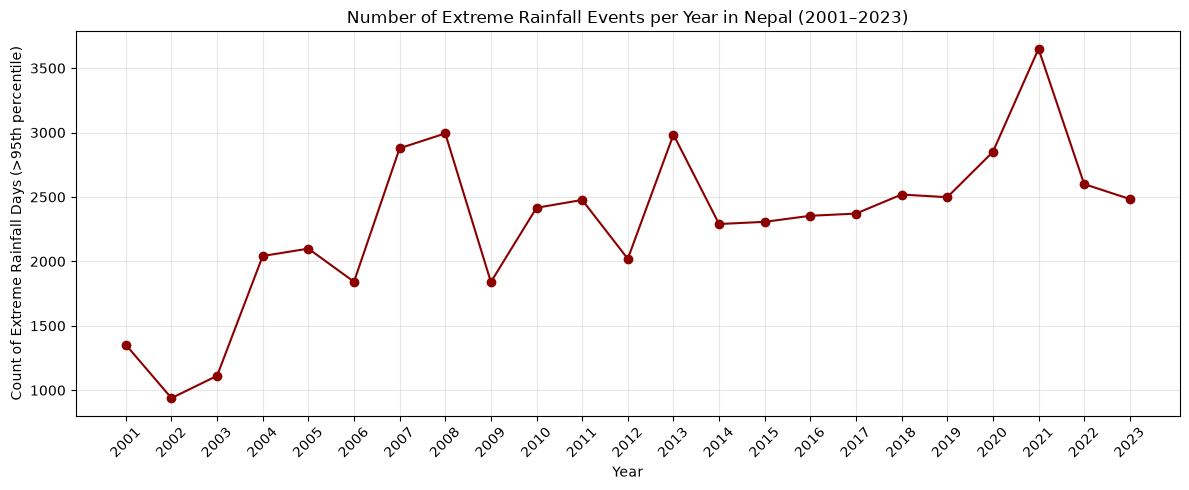

In [18]:
extreme_per_year.plot(kind='line', figsize=(12,5), marker='o', color='darkred')
plt.title('Number of Extreme Rainfall Events per Year in Nepal (2001–2023)')
plt.xlabel('Year')
plt.ylabel('Count of Extreme Rainfall Days (>95th percentile)')
plt.xticks(ticks=extreme_per_year.index, labels=extreme_per_year.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
slope_ext, intercept_ext, r_value_ext, p_value_ext, std_err_ext = stats.linregress(extreme_per_year.index, extreme_per_year.values)

print(f"Slope: {slope_ext:.2f} extreme events per year")
print(f"R-squared: {r_value_ext**2:.3f}")
print(f"P-value: {p_value_ext:.4f}")

Slope: 61.04 extreme events per year
R-squared: 0.447
P-value: 0.0005


**Result:** The number of extreme rainfall events (days exceeding the 95th percentile threshold) has increased significantly over 2001–2023 (p = 0.0005), though with a moderate fit (R² = 0.447), meaning a real upward trend exists but with substantial year to year variability. This mirrors the pattern seen in total annual rainfall, and is consistent with the broader research finding that monsoon rainfall intensity and frequency of extreme events in Nepal have increased since 1980.

This is a more directly relevant finding for flood risk than total rainfall alone: floods are typically triggered by concentrated, intense rainfall events rather than gradual accumulation, so an increase in extreme-rainfall-day frequency is a meaningful indicator of potentially rising flood risk over time.

### Are the most extreme events getting more intense?

Rather than just counting how many extreme days occur each year, we look at the single most intense rainfall day recorded each year (across all locations). This tests a different question: are the worst rainfall events becoming more severe not just more frequent? This connects directly to the climate change mechanism discussed earlier. A warmer atmosphere can hold more moisture, which would show up as heavier peak rainfall events, not necessarily more total rainy days.

In [20]:
max_per_year = df.groupby('year')['rainfall_mm'].max()
max_per_year

year
2001    117.45
2002    122.59
2003    103.52
2004    124.89
2005    185.72
2006    152.19
2007    110.77
2008    168.02
2009    166.20
2010    100.32
2011    207.09
2012    116.61
2013    177.18
2014    122.93
2015    104.04
2016    118.85
2017    139.54
2018    103.35
2019    157.03
2020    464.92
2021    213.33
2022    279.27
2023    105.12
Name: rainfall_mm, dtype: float64

We visualize the yearly maximum rainfall values and run the same trend test to check whether extreme-event *intensity* shows a significant trend, unlike the frequency trend seen above.

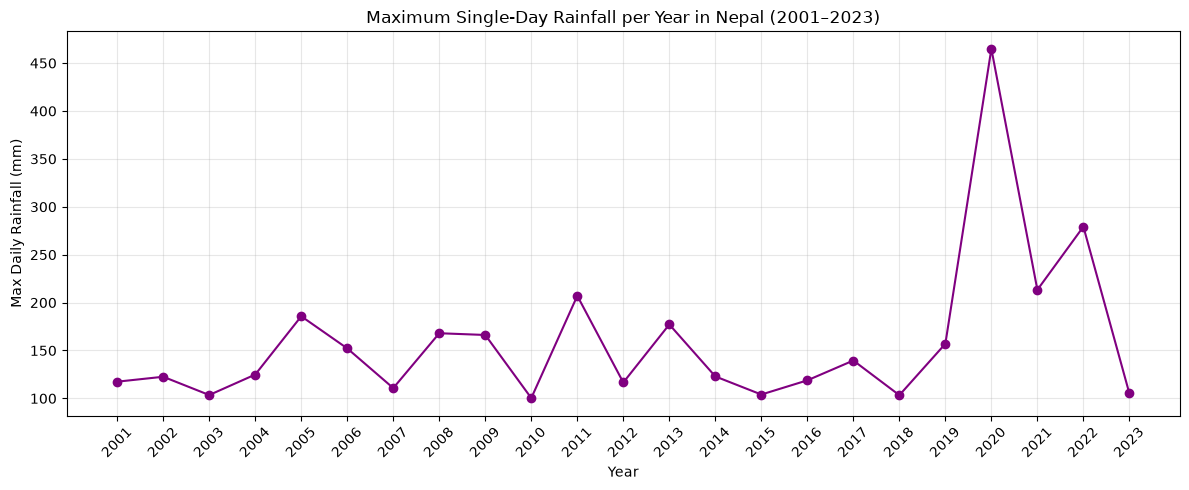

In [21]:
max_per_year.plot(kind='line', figsize=(12,5), marker='o', color='purple')
plt.title('Maximum Single-Day Rainfall per Year in Nepal (2001–2023)')
plt.xlabel('Year')
plt.ylabel('Max Daily Rainfall (mm)')
plt.xticks(ticks=max_per_year.index, labels=max_per_year.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
slope_max, intercept_max, r_value_max, p_value_max, std_err_max = stats.linregress(max_per_year.index, max_per_year.values)

print(f"Slope: {slope_max:.2f} mm per year")
print(f"R-squared: {r_value_max**2:.3f}")
print(f"P-value: {p_value_max:.4f}")

Slope: 4.37 mm per year
R-squared: 0.136
P-value: 0.0829


**Result:** Unlike the frequency of extreme rainfall days (which showed a significant upward trend), the intensity of the single most extreme rainfall day each year shows no statistically significant trend over 2001–2023 (p = 0.083, R² = 0.136). The pattern is dominated by a few outlier years (notably 2020, with a maximum of 464.92mm), rather than a steady increase.

**Interpretation:** This suggests that in our dataset, climate-related change shows up more clearly as an *increase in how often* extreme rainfall occurs, rather than a clear increase in the *ceiling* of how intense the single worst event gets. This is a meaningful distinction for flood risk more frequent extreme rainfall days could mean more frequent flood triggering conditions, even without necessarily record breaking single day totals. However, with only one maximum value per year (23 data points total), this test has limited statistical power and a longer time series would be needed to draw firmer conclusions about extreme intensity trends specifically.

### Where do extreme rainfall events happen most?

So far we've looked at extreme rainfall over time, treating Nepal as a whole. Now we look across space which locations (grid points) experience extreme rainfall days most often. This starts to connect our rainfall analysis to geography which matters for understanding *where* flood risk may be concentrated.

In [23]:
extreme_by_location = df.groupby(['latitude', 'longitude'])['is_extreme'].sum().reset_index()
extreme_by_location = extreme_by_location.sort_values('is_extreme', ascending=False)
extreme_by_location.head(10)

,latitude,longitude,is_extreme
13,26.5,88.125,1066
27,27.0,88.125,952
48,28.0,83.750,908
49,28.0,84.375,855
35,27.5,84.375,837
62,28.5,83.750,827
61,28.5,83.125,805
47,28.0,83.125,799
34,27.5,83.750,787
12,26.5,87.500,784


**Result:** Extreme rainfall events are not evenly distributed across Nepal they cluster strongly in two regions: far eastern Nepal (near longitude 88°, close to the India/Bangladesh border) and central Nepal around longitude 83–84° (the Pokhara/Annapurna foothill region).

This matches well documented climatology: the central Himalayan foothill region (near Pokhara) is known as one of the highest rainfall areas in South Asia due to orographic lift, moist monsoon air is forced rapidly upward by the sudden rise of the Annapurna range, causing intense condensation and rainfall. This geographic clustering is a strong sign our satellite derived dataset is capturing real, physically sensible patterns rather than noise.

This also has direct flood risk relevance: these high extreme rainfall regions are natural candidates for elevated flood risk, and would be priority areas if reliable flood event data becomes available for Stage 5.

**Note on scope:** The catastrophic Nepal-Tibet flood of August 26, 2026, which motivated this project, was caused by a glacier collapse on Langtang Lirung not by rainfall (no rain was reported in the area that morning). This project examines Nepal's broader rainfall driven flood risk, which is a distinct but related hazard category. Our dataset cannot speak to glacier or permafrost related disasters.

### Mapping extreme rainfall hotspots

We visualize the geographic distribution of extreme rainfall events across Nepal, using each grid point's location and its count of extreme rainfall days. This gives a spatial view of where extreme rainfall risk is concentrated.

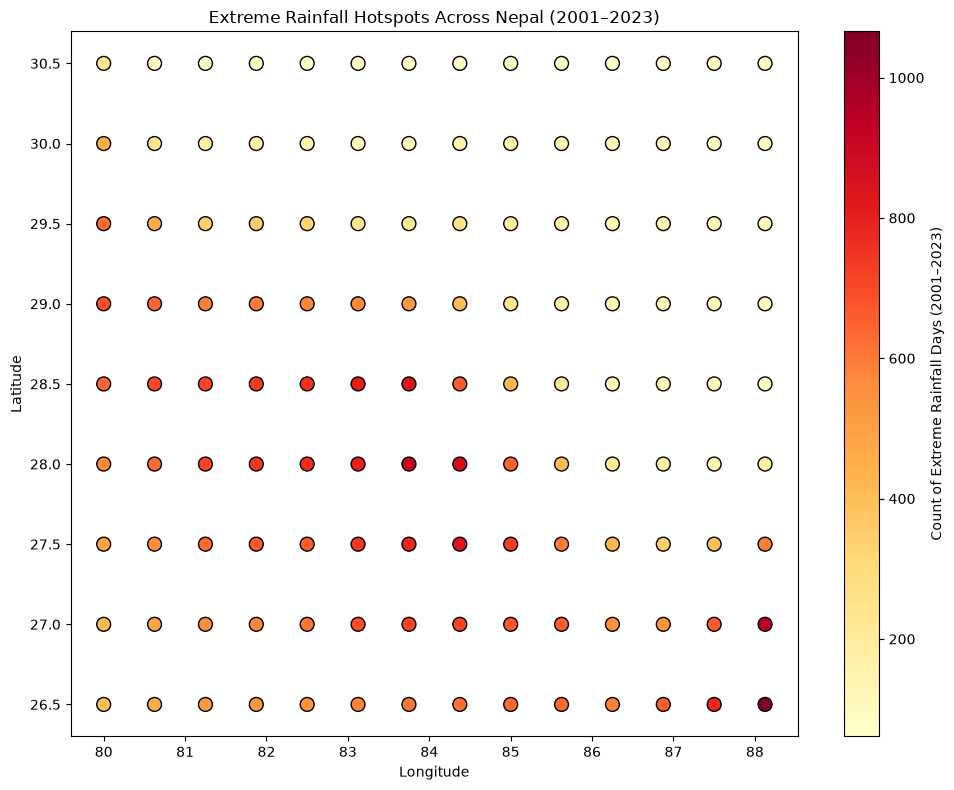

In [24]:
plt.figure(figsize=(10,8))
scatter = plt.scatter(
    extreme_by_location['longitude'],
    extreme_by_location['latitude'],
    c=extreme_by_location['is_extreme'],
    cmap='YlOrRd',
    s=100,
    edgecolors='black'
)
plt.colorbar(scatter, label='Count of Extreme Rainfall Days (2001–2023)')
plt.title('Extreme Rainfall Hotspots Across Nepal (2001–2023)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

### Building a map with Nepal's actual boundary

We first tried an interactive map (using folium), but found it too visually cluttered to read clearly (see below). We switch to a static map using geopandas, combined with Nepal's official boundary shape, for a cleaner result.

<Axes: >

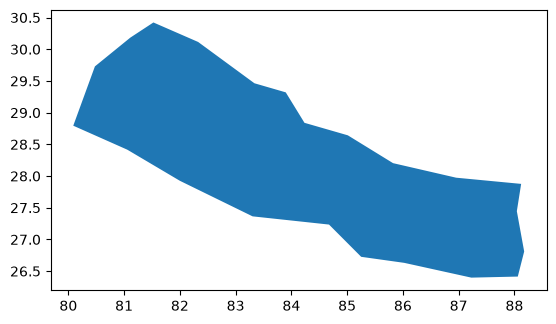

In [25]:


world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
nepal_border = world[world['NAME'] == 'Nepal']

nepal_border.plot()

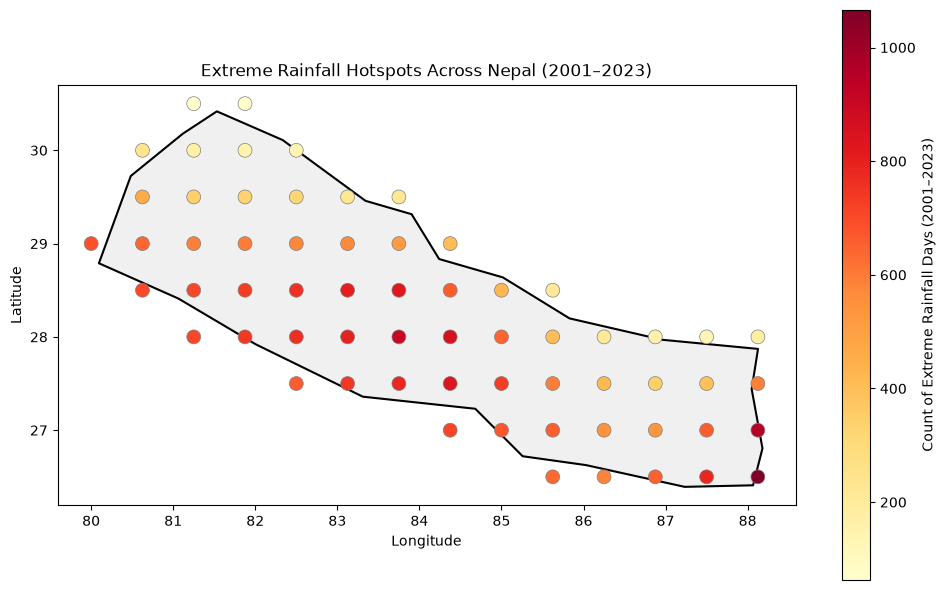

In [29]:


# Buffer Nepal's border slightly to keep near-border points
nepal_shape = nepal_border.geometry.iloc[0]
buffered_nepal = nepal_shape.buffer(0.3)

extreme_by_location['inside_nepal'] = extreme_by_location.apply(
    lambda row: buffered_nepal.contains(Point(row['longitude'], row['latitude'])), axis=1
)

filtered_points = extreme_by_location[extreme_by_location['inside_nepal']]

fig, ax = plt.subplots(figsize=(10, 6))

nepal_border.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.5)

scatter = ax.scatter(
    filtered_points['longitude'],
    filtered_points['latitude'],
    c=filtered_points['is_extreme'],
    cmap='YlOrRd',
    s=100,
    edgecolors='grey',
    linewidths=0.5
)

plt.colorbar(scatter, label='Count of Extreme Rainfall Days (2001–2023)')
plt.title('Extreme Rainfall Hotspots Across Nepal (2001–2023)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

### Note on visualization choice

We use a static map here (rather than the earlier interactive folium version) because it renders reliably without depending on external map tile servers, and static maps are the standard format for reports and portfolio documentation. The map shows only grid points falling within or near Nepal's actual border, colored by the count of extreme rainfall days recorded at each location (2001–2023).

**Limitation:** Since our data is on a fixed 0.5° grid (~55km spacing), this map shows broad regional patterns rather than precise local detail. It cannot capture rainfall variation at the scale of individual valleys or towns. For a more polished or interactive version of this map in the future, tools like Tableau or a refined GIS approach could provide smoother, higher resolution visualizations.

## Stage 5: Flood-Risk Connection

Now that we understand Nepal's rainfall patterns and extreme rainfall trends, we look for reliable flood-event data to investigate whether periods of extreme rainfall correspond with recorded flood events. This is the step that connects our rainfall analysis to actual flood risk, rather than just rainfall patterns alone.

We will evaluate any dataset we find on:
- Source credibility
- Time period overlap with our rainfall data (2001–2023)
- Geographic detail (can we match it to our grid points/regions?)
- Whether dates/locations are precise enough to compare against daily rainfall

### Candidate flood-event datasets

Two established, credible disaster databases could provide flood-event data for Nepal:

1. **EM-DAT** (International Disaster Database): maintained by CRED (Centre for Research on the Epidemiology of Disasters), covering 1900–present globally. Widely used in academic research.
2. **DesInventar**: a disaster inventory system with a dedicated Nepal specific database, recording historical disaster events including floods, landslides, and GLOFs by location.

Note: published research comparing these two databases found meaningful differences in the number of recorded events and damage estimates between them, so we should evaluate whichever we use carefully, rather than assume either is complete or fully accurate.

Next, we check each database directly for accessible, usable Nepal flood data covering our 2001–2023 period.

### Evaluating EM-DAT as our flood data source

EM-DAT (maintained by CRED, University of Louvain, Belgium) is a highly credible, widely used source cited by organizations including IFRC, IOM, and numerous universities, running since 1988, open access for non commercial use.

**Important scope note:** EM-DAT only records disasters meeting at least one of these thresholds: 10+ fatalities, 100+ people affected, a declared state of emergency, or a call for international assistance. This means it captures major flood events, not minor/local flooding. For our purposes connecting extreme rainfall to significant flood risk, this is an appropriate scope, though it means we will only be able to analyze large scale flood events, not every flooding incident in Nepal.

Next, we access EM-DAT's data portal to check what Nepal specific flood records are available for our 2001–2023 period.

### Loading flood event data

We load the Nepal flood event data downloaded from EM-DAT (34 records, 2001–2023) and inspect its structure before working with it.

In [31]:
flood_df = pd.read_csv('nepal_flood_events_emdat.csv')
print(flood_df.shape)
flood_df.head()

(34, 47)


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2017-0342-NPL,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2017-000084,NaN,NPL,...,NaN,NaN,NaN,595000.0,781480.0,76.137604,"[{""adm2_code"":22351,""adm2_name"":""Bagmati""},{""a...","[{""gid_2"":""NPL.1.1_1"",""migration_date"":""2025-1...",2017-08-18,2025-12-20
1,2022-0590-NPL,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,NPL,...,NaN,NaN,NaN,NaN,NaN,90.902697,NaN,"[{""gid_2"":""NPL.3.1_1"",""name_2"":""Mahakali""}]",2022-09-13,2026-02-11
2,2016-0275-NPL,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,NPL,...,NaN,NaN,NaN,NaN,NaN,74.549603,"[{""adm2_code"":22351,""adm2_name"":""Bagmati""},{""a...","[{""gid_2"":""NPL.1.1_1"",""migration_date"":""2025-1...",2016-08-05,2025-12-20
3,2014-0246-NPL,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,NPL,...,NaN,NaN,NaN,NaN,NaN,73.533577,"[{""adm2_code"":22351,""adm2_name"":""Bagmati""},{""a...","[{""gid_2"":""NPL.1.1_1"",""migration_date"":""2025-1...",2014-07-25,2025-12-20
4,2023-0326-NPL,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,NPL,...,NaN,NaN,NaN,NaN,NaN,94.644622,NaN,NaN,2023-06-26,2023-09-26


### Understanding the flood dataset structure

The EM-DAT dataset has 47 columns, most of which we won't need. We first look at all available columns then select only the ones relevant to our analysis, primarily event dates and location.

In [32]:
list(flood_df.columns)

['DisNo.',
 'Historic',
 'Classification Key',
 'Disaster Group',
 'Disaster Subgroup',
 'Disaster Type',
 'Disaster Subtype',
 'External IDs',
 'Event Name',
 'ISO',
 'Country',
 'Subregion',
 'Region',
 'Location',
 'Origin',
 'Associated Types',
 'OFDA/BHA Response',
 'Appeal',
 'Declaration',
 "AID Contribution ('000 US$)",
 'Magnitude',
 'Magnitude Scale',
 'Latitude',
 'Longitude',
 'River Basin',
 'Start Year',
 'Start Month',
 'Start Day',
 'End Year',
 'End Month',
 'End Day',
 'Total Deaths',
 'No. Injured',
 'No. Affected',
 'No. Homeless',
 'Total Affected',
 "Reconstruction Costs ('000 US$)",
 "Reconstruction Costs, Adjusted ('000 US$)",
 "Insured Damage ('000 US$)",
 "Insured Damage, Adjusted ('000 US$)",
 "Total Damage ('000 US$)",
 "Total Damage, Adjusted ('000 US$)",
 'CPI',
 'Admin Units',
 'GADM Admin Units',
 'Entry Date',
 'Last Update']

### Selecting relevant columns

We narrow the dataset down to the columns needed for our analysis: event identification, dates, location (including coordinates), and impact severity (deaths/affected people, to help us judge each event's significance).

In [33]:
flood_clean = flood_df[[
    'DisNo.', 'Disaster Subtype', 'Location', 'Latitude', 'Longitude',
    'Start Year', 'Start Month', 'Start Day',
    'End Year', 'End Month', 'End Day',
    'Total Deaths', 'Total Affected'
]].copy()

flood_clean.head(10)

,DisNo.,Disaster Subtype,Location,Latitude,Longitude,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,Total Affected
0,2017-0342-NPL,Flood (General),"Lalitpur, Palpa, Jhapa, Morang, Sunsari, Sapta...",27.941,83.878,2017,8,10.0,2017,9,7.0,176.0,1700134.0
1,2022-0590-NPL,Flood (General),Darchula District (Sudurpashchim Provincel); K...,NaN,NaN,2022,9,9.0,2022,9,17.0,15.0,511.0
2,2016-0275-NPL,Flood (General),"Rapti, Kerauja VDC, Gorkha, Lamjung (Gandaki);...",NaN,NaN,2016,6,29.0,2016,7,5.0,25.0,10023.0
3,2014-0246-NPL,Riverine flood,"Sindhupalchok, Lalitpur areas (Bagmati distric...",NaN,NaN,2014,7,1.0,2014,7,14.0,16.0,2400.0
4,2023-0326-NPL,Flood (General),"Nuwakot, Okhaldhunga, Panchthar, Shankhuwasabh...",NaN,NaN,2023,6,15.0,2023,6,19.0,36.0,1506.0
5,2004-0298-NPL,Riverine flood,"Morang, Sunsari areas (Koshi district, Eastern...",NaN,NaN,2004,7,5.0,2004,7,13.0,185.0,800015.0
6,2005-0556-NPL,Riverine flood,"Kanchanpur, Baitadi, Dadeldhura, Darchula area...",NaN,NaN,2005,9,24.0,2005,9,29.0,51.0,1600.0
7,2006-0342-NPL,Riverine flood,"Banke area (Bheri district, Mid Western provin...",25.620,83.670,2006,6,24.0,2006,8,3.0,NaN,NaN
8,2007-0307-NPL,Riverine flood,"Mahottari, Dhanusha, Sindhuli areas (Janakpur ...",27.780,84.080,2007,7,23.0,2007,10,2.0,214.0,640706.0
9,2008-0271-NPL,Riverine flood,"Kusaha, Laukahi, Ghuski, Shripur, Haripur, Nar...",NaN,NaN,2008,7,NaN,2008,8,NaN,65.0,70000.0


### Checking data completeness

Before matching flood events to rainfall data, we check how much missing data exists, particularly in Latitude/Longitude (needed for geographic matching) and dates (needed for temporal matching).

In [34]:
flood_clean.isnull().sum()

DisNo.               0
Disaster Subtype     0
Location             0
Latitude            24
Longitude           24
Start Year           0
Start Month          0
Start Day            3
End Year             0
End Month            0
End Day              3
Total Deaths         2
Total Affected       5
dtype: int64

**Result:** 24 of 34 flood records (71%) are missing latitude/longitude coordinates, while dates (Start Year/Month) are complete for all records, and Start Day is missing for only 3 events.

**Revised approach:** Given this, we will primarily use **temporal matching**, checking whether recorded flood events coincide with periods of extreme rainfall in our dataset rather than precise geographic matching. The `Location` field (fully populated, containing district/region names) can still support a general geographic sanity check, but not exact coordinate level matching.

### Building start and end dates

We combine the separate Year/Month/Day columns into proper date columns. For the 3 events missing a specific day, we use the 1st of the month as a reasonable placeholder, and note this as a minor limitation for these few events, we only know the month, not the exact day.

In [35]:
flood_clean['Start Day'] = flood_clean['Start Day'].fillna(1)
flood_clean['End Day'] = flood_clean['End Day'].fillna(1)

flood_clean['start_date'] = pd.to_datetime(
    flood_clean[['Start Year', 'Start Month', 'Start Day']].astype(int).astype(str).agg('-'.join, axis=1),
    format='%Y-%m-%d'
)

flood_clean['end_date'] = pd.to_datetime(
    flood_clean[['End Year', 'End Month', 'End Day']].astype(int).astype(str).agg('-'.join, axis=1),
    format='%Y-%m-%d'
)

flood_clean[['DisNo.', 'start_date', 'end_date']].head(10)

,DisNo.,start_date,end_date
0,2017-0342-NPL,2017-08-10,2017-09-07
1,2022-0590-NPL,2022-09-09,2022-09-17
2,2016-0275-NPL,2016-06-29,2016-07-05
3,2014-0246-NPL,2014-07-01,2014-07-14
4,2023-0326-NPL,2023-06-15,2023-06-19
5,2004-0298-NPL,2004-07-05,2004-07-13
6,2005-0556-NPL,2005-09-24,2005-09-29
7,2006-0342-NPL,2006-06-24,2006-08-03
8,2007-0307-NPL,2007-07-23,2007-10-02
9,2008-0271-NPL,2008-07-01,2008-08-01


### Connecting flood events to rainfall data

For each flood event, we check the rainfall recorded (across all Nepal grid points) during that event's date range, to see whether flood periods coincide with high or extreme rainfall or whether some floods occurred without notably high rainfall (which could indicate glacier/dam related causes, human factors, or data limitations).

In [36]:
def get_rainfall_during_event(row):
    mask = (df['date'] >= row['start_date']) & (df['date'] <= row['end_date'])
    event_rainfall = df.loc[mask, 'rainfall_mm']
    return pd.Series({
        'avg_rainfall_during_event': event_rainfall.mean(),
        'max_rainfall_during_event': event_rainfall.max(),
        'extreme_days_during_event': df.loc[mask, 'is_extreme'].sum()
    })

flood_clean[['avg_rainfall_during_event', 'max_rainfall_during_event', 'extreme_days_during_event']] = flood_clean.apply(get_rainfall_during_event, axis=1)

flood_clean[['DisNo.', 'start_date', 'end_date', 'avg_rainfall_during_event', 'max_rainfall_during_event', 'extreme_days_during_event']]

,DisNo.,start_date,end_date,avg_rainfall_during_event,max_rainfall_during_event,extreme_days_during_event
0,2017-0342-NPL,2017-08-10,2017-09-07,7.108571,139.54,595.0
1,2022-0590-NPL,2022-09-09,2022-09-17,9.834048,99.47,230.0
2,2016-0275-NPL,2016-06-29,2016-07-05,11.234785,118.85,255.0
3,2014-0246-NPL,2014-07-01,2014-07-14,5.660147,44.54,207.0
4,2023-0326-NPL,2023-06-15,2023-06-19,3.865714,36.65,44.0
5,2004-0298-NPL,2004-07-05,2004-07-13,13.550529,88.74,400.0
6,2005-0556-NPL,2005-09-24,2005-09-29,2.176402,44.83,41.0
7,2006-0342-NPL,2006-06-24,2006-08-03,7.381531,152.19,835.0
8,2007-0307-NPL,2007-07-23,2007-10-02,6.902615,110.77,1628.0
9,2008-0271-NPL,2008-07-01,2008-08-01,9.686384,119.60,953.0


**Initial observation:** The vast majority of flood events coincide with periods of elevated or extreme rainfall supporting a real connection between rainfall and flooding in our data. However, two events (2012-0186-NPL and 2010-0333-NPL) show no extreme rainfall at all during their recorded window, suggesting alternative causes (e.g., dam/embankment failure, upstream rainfall outside our data's coverage, or reporting/data limitations).

**Methodological note:** Event windows vary greatly in length (1 day to ~3 months), so raw counts of extreme days aren't directly comparable across events. A longer window naturally accumulates more extreme days. We calculate an extreme day *rate* (extreme days ÷ event length) for a fairer comparison.

In [37]:
flood_clean['event_length_days'] = (flood_clean['end_date'] - flood_clean['start_date']).dt.days + 1
flood_clean['extreme_day_rate'] = flood_clean['extreme_days_during_event'] / flood_clean['event_length_days']

flood_clean[['DisNo.', 'event_length_days', 'extreme_days_during_event', 'extreme_day_rate']].sort_values('extreme_day_rate', ascending=False)

,DisNo.,event_length_days,extreme_days_during_event,extreme_day_rate
29,2009-0608-NPL,3,228.0,76.000000
16,2016-0267-NPL,3,160.0,53.333333
31,2010-0452-NPL,4,208.0,52.000000
5,2004-0298-NPL,9,400.0,44.444444
14,2014-0268-NPL,7,302.0,43.142857
18,2021-0681-NPL,7,282.0,40.285714
25,2021-0308-NPL,2,75.0,37.500000
2,2016-0275-NPL,7,255.0,36.428571
33,2019-0332-NPL,22,782.0,35.545455
20,2005-0375-NPL,21,708.0,33.714286


**Result:** After adjusting for event length, 32 of 34 recorded flood events (94%) show a meaningful rate of extreme rainfall days during their window confirming a strong, consistent association between extreme rainfall and flood events in Nepal, even for short-duration events.

Two events show no extreme rainfall at all (2012-0186-NPL, 2010-0333-NPL, both rate = 0). These are worth investigating individually possible explanations include dam/infrastructure failure, flooding driven by rainfall upstream/outside our dataset's coverage area, or snowmelt driven flooding rather than rainfall driven flooding.

**Important caution:** This is an association, not proof of causation for every individual event. Flooding is influenced by many factors beyond rainfall alone, river management, upstream conditions, terrain, and infrastructure. However, the strength and consistency of this pattern across 94% of recorded events provides meaningful evidence that extreme rainfall is a major driver of flood risk in Nepal, consistent with our project's original research question.

In [39]:
flood_clean[flood_clean['DisNo.'].isin(['2012-0186-NPL', '2010-0333-NPL'])][['DisNo.', 'Disaster Subtype', 'Location', 'start_date', 'end_date']]

,DisNo.,Disaster Subtype,Location,start_date,end_date
12,2012-0186-NPL,Riverine flood,"Kaski area (Gandaki district, Western province)",2012-05-05,2012-05-07
30,2010-0333-NPL,Riverine flood,"Sunsari area (Koshi district, Eastern province...",2010-07-25,2010-07-25


### Investigating the two outlier events

Both zero rainfall flood events are classified as **Riverine floods**: flooding caused by a river overflowing its banks, rather than direct local rainfall flooding. Notably, the 2012 event occurred in Kaski district, part of the same region we identified earlier as Nepal's highest rainfall hotspot (Pokhara/Lumle), making the absence of extreme rainfall at the time genuinely notable.

**Likely explanation:** Riverine floods are often driven by rainfall or snowmelt occurring upstream in a river's broader catchment area, sometimes days earlier or in an entirely different location than where the flood itself occurs. Our rainfall dataset only captures conditions at the flood's recorded location and date, it cannot account for rainfall elsewhere in the river's watershed that may have caused the flood downstream. This is a reasonable, data supported explanation for these two exceptions, and highlights an inherent limitation of location matched rainfall analysis for riverine (as opposed to flash) flooding.

## Stage 6: Visualization (integrated throughout)

Rather than treating visualization as a separate final stage, charts and maps were created throughout the analysis as each question required them the monthly rainfall bar chart, the annual trend line chart, the extreme events frequency chart, and the final geographic hotspot map with Nepal's boundary. This kept each visualization directly tied to the analysis that produced it, rather than separated from its context.

## Stage 7: Conclusions

### Key Findings

1. **Seasonal patterns:** Nepal's rainfall is heavily concentrated in the monsoon season (June–September), accounting for 79.03% of total rainfall in our dataset closely matching Nepal's Department of Hydrology and Meteorology's official figure of ~80%.

2. **Annual trend:** Total annual rainfall showed a statistically significant increase from 2001–2023 (p < 0.0001), though with substantial year to year variability (R² = 0.553).

3. **Extreme rainfall frequency:** The number of extreme rainfall days per year increased significantly over the same period (p = 0.0005), consistent with published research on Nepal's changing monsoon patterns.

4. **Extreme rainfall intensity:** Unlike frequency, the intensity of the single most extreme rainfall day per year showed no statistically significant trend (p = 0.083) suggesting climate related change shows up more clearly in *how often* extreme rainfall occurs than in record-breaking single-day totals, within this dataset and time period.

5. **Geographic concentration:** Extreme rainfall clusters strongly in central Nepal (Pokhara/Annapurna foothill region) and far eastern Nepal independently matching real world records showing Lumle, in this same region, holds Nepal's highest recorded annual rainfall.

6. **Rainfall–flood connection:** 32 of 34 recorded major flood events (94%) coincided with a meaningful rate of extreme rainfall days, providing quantitative evidence linking extreme rainfall to flood risk in Nepal. The 2 exceptions were both riverine floods, plausibly explained by upstream rainfall outside our location based dataset's coverage.

### Limitations

- Our rainfall dataset is satellite derived (NASA POWER/MERRA-2), not ground station data, highly consistent over time, but still a modeled estimate rather than direct measurement.
- A rectangular grid was used for regional coverage, meaning a few grid points fall slightly outside Nepal's actual border.
- Flood event data (EM-DAT) only includes major disasters meeting specific severity thresholds, not all flooding incidents, and 71% of records lacked precise coordinates, limiting geographic (though not temporal) matching precision.
- This analysis identifies patterns and associations, it does not establish causation, particularly regarding climate change attribution, which would require specialized climate modeling beyond this project's scope.
- The catastrophic August 2026 Rasuwa/Trishuli disaster that motivated this project was a glacier/bedrock collapse, not a rainfall-driven flood, a separate hazard category this rainfall focused analysis cannot address.

### Possible Future Improvements

- Incorporate ground station data from Nepal's DHM where available, to cross validate satellite estimates
- Use precise river basin/catchment boundaries rather than point-based grid matching, to better capture upstream rainfall effects on riverine floods
- Extend the time period further back (NASA POWER data exists from 1981) for a longer trend baseline
- Investigate cryosphere-specific hazards (glacial lake outburst floods, glacier collapse risk) as a separate, complementary analysis using appropriate specialized data